In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [2]:
# Number of customers
n = 1000

# Generate dataset
data = {
    'customerID': np.arange(1, n + 1),
    
    'gender': np.random.choice(['Male', 'Female'], n),
    
    'tenure': np.random.randint(1, 72, n),
    
    'MonthlyCharges': np.random.randint(20, 120, n),
    
    'Contract': np.random.choice(
        ['Month-to-month', 'One year', 'Two year'],
        n,
        p=[0.6, 0.25, 0.15]
    ),
    
    'InternetService': np.random.choice(
        ['DSL', 'Fiber optic', 'No'],
        n,
        p=[0.4, 0.5, 0.1]
    ),
    
    'TechSupport': np.random.choice(
        ['Yes', 'No'],
        n,
        p=[0.3, 0.7]
    )
}

# Create DataFrame
df = pd.DataFrame(data)

# Create churn logic
df['Churn'] = np.where(
    (
        (df['Contract'] == 'Month-to-month') &
        (df['MonthlyCharges'] > 80)
    ) |
    (
        (df['TechSupport'] == 'No') &
        (df['tenure'] < 12)
    ),
    'Yes',
    'No'
)

# Display first rows
df.head()

,customerID,gender,tenure,MonthlyCharges,Contract,InternetService,TechSupport,Churn
0,1,Male,63,50,Month-to-month,Fiber optic,Yes,No
1,2,Female,17,30,Month-to-month,Fiber optic,No,No
2,3,Male,33,29,Month-to-month,Fiber optic,Yes,No
3,4,Male,29,86,Two year,No,No,No
4,5,Male,13,33,Two year,DSL,No,No


In [3]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Data types
df.info()

Dataset Shape: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customerID       1000 non-null   int64 
 1   gender           1000 non-null   object
 2   tenure           1000 non-null   int32 
 3   MonthlyCharges   1000 non-null   int32 
 4   Contract         1000 non-null   object
 5   InternetService  1000 non-null   object
 6   TechSupport      1000 non-null   object
 7   Churn            1000 non-null   object
dtypes: int32(2), int64(1), object(5)
memory usage: 54.8+ KB


In [4]:
# Missing values
df.isnull().sum()

customerID         0
gender             0
tenure             0
MonthlyCharges     0
Contract           0
InternetService    0
TechSupport        0
Churn              0
dtype: int64

In [5]:
# Preview dataset
df.head()

,customerID,gender,tenure,MonthlyCharges,Contract,InternetService,TechSupport,Churn
0,1,Male,63,50,Month-to-month,Fiber optic,Yes,No
1,2,Female,17,30,Month-to-month,Fiber optic,No,No
2,3,Male,33,29,Month-to-month,Fiber optic,Yes,No
3,4,Male,29,86,Two year,No,No,No
4,5,Male,13,33,Two year,DSL,No,No


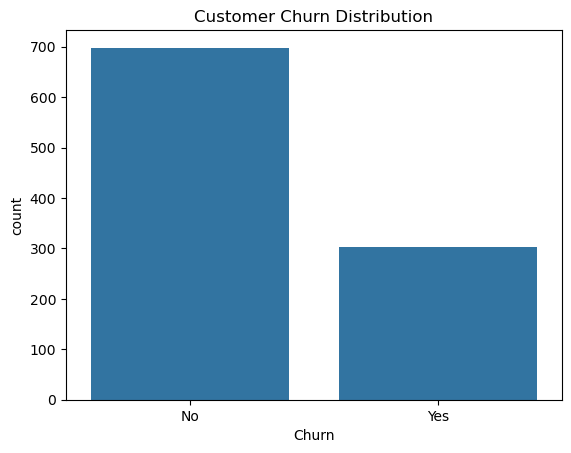

In [6]:
# Churn count
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

In [7]:
# Convert categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Preview encoded dataset
df_encoded.head()

,customerID,tenure,MonthlyCharges,gender_Male,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,TechSupport_Yes,Churn_Yes
0,1,63,50,True,False,False,True,False,True,False
1,2,17,30,False,False,False,True,False,False,False
2,3,33,29,True,False,False,True,False,True,False
3,4,29,86,True,False,True,False,True,False,False
4,5,13,33,True,False,True,False,False,False,False


In [8]:
# Features
X = df_encoded.drop('Churn_Yes', axis=1)

# Target
y = df_encoded['Churn_Yes']

print(X.shape)
print(y.shape)

(1000, 9)
(1000,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 9)
Testing data: (200, 9)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression

# Create model
lr = LogisticRegression(max_iter=500)

# Train model
lr.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [14]:
# Predictions
y_pred_lr = lr.predict(X_test)

# Probability predictions
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("LOGISTIC REGRESSION RESULTS")
print("-" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
----------------------------------------
Accuracy: 0.83
Precision: 0.75
Recall: 0.703125
F1 Score: 0.7258064516129032
ROC-AUC Score: 0.9001608455882353

Classification Report
              precision    recall  f1-score   support

       False       0.86      0.89      0.88       136
        True       0.75      0.70      0.73        64

    accuracy                           0.83       200
   macro avg       0.81      0.80      0.80       200
weighted avg       0.83      0.83      0.83       200



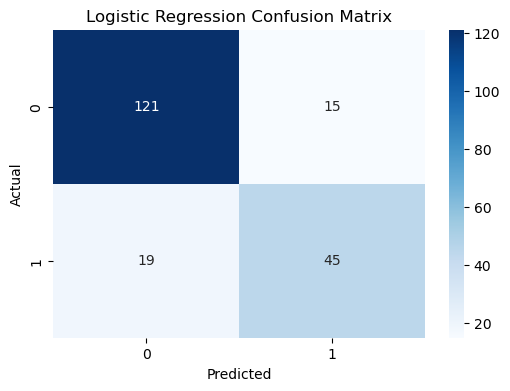

In [16]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

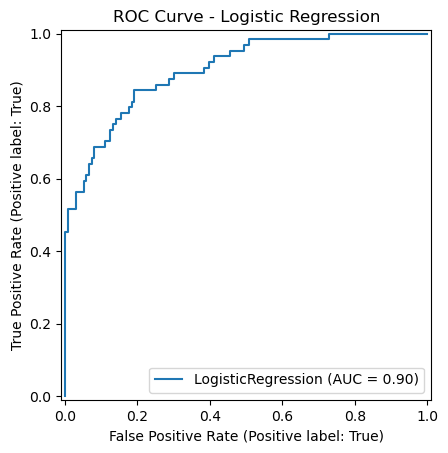

In [17]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(lr, X_test, y_test)

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [18]:
from sklearn.tree import DecisionTreeClassifier

# Create model
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train model
dt.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [19]:
# Predictions
y_pred_dt = dt.predict(X_test)

# Probabilities
y_prob_dt = dt.predict_proba(X_test)[:,1]

print("DECISION TREE RESULTS")
print("-" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_dt))

DECISION TREE RESULTS
----------------------------------------
Accuracy: 0.995
Precision: 1.0
Recall: 0.984375
F1 Score: 0.9921259842519685
ROC-AUC Score: 0.9921875


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [21]:
# Predictions
y_pred_rf = rf.predict(X_test)

# Probabilities
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("RANDOM FOREST RESULTS")
print("-" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

RANDOM FOREST RESULTS
----------------------------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC Score: 1.0


In [22]:
# Create comparison table

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.830,0.75,0.703125,0.725806,0.900161
1,Decision Tree,0.995,1.00,0.984375,0.992126,0.992188
2,Random Forest,1.000,1.00,1.000000,1.000000,1.000000


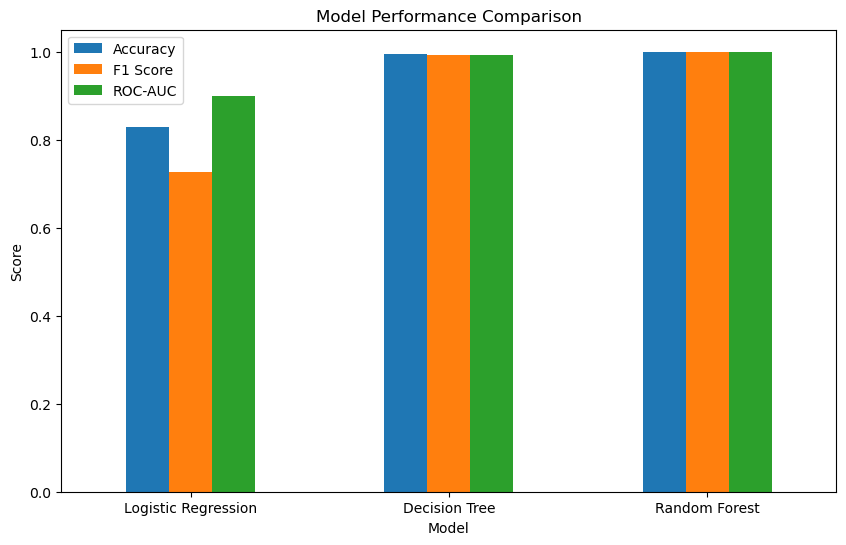

In [23]:
results.set_index('Model')[['Accuracy', 'F1 Score', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

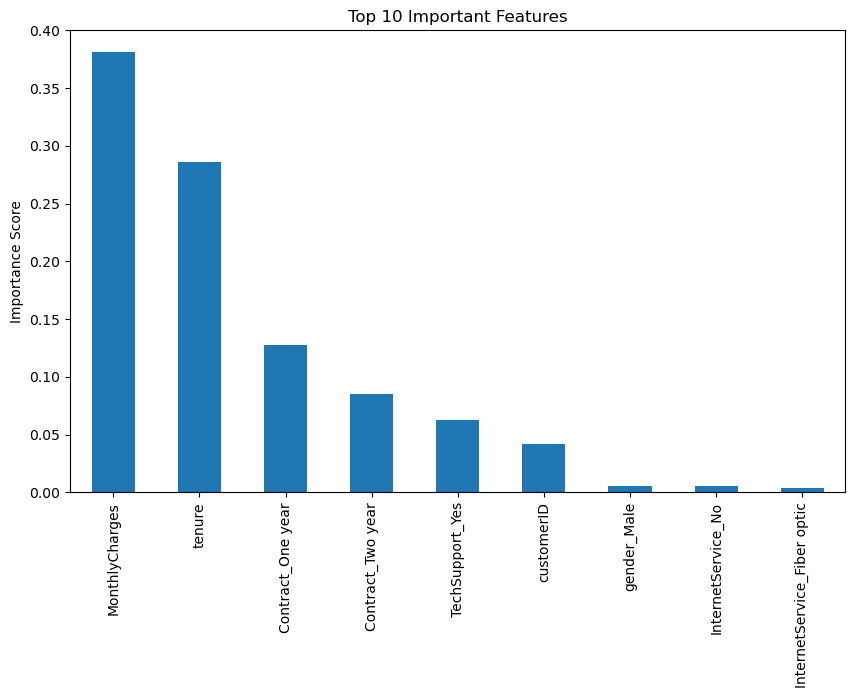

In [24]:
# Get feature names
feature_names = X.columns

# Feature importance
importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
)

# Top 10 important features
top_features = importances.sort_values(
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(10,6))

top_features.plot(
    kind='bar'
)

plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")

plt.show()

In [25]:
print(top_features)

MonthlyCharges                 0.381134
tenure                         0.286038
Contract_One year              0.127750
Contract_Two year              0.085499
TechSupport_Yes                0.062935
customerID                     0.041846
gender_Male                    0.005652
InternetService_No             0.005126
InternetService_Fiber optic    0.004019
dtype: float64


# Final Project Summary

## Objective
The objective of this project was to build machine learning classification models capable of predicting customer churn based on customer demographics, subscription information, and service usage patterns.

## Dataset Overview
The dataset contained 1000 customer records with multiple customer-related features such as:
- Gender
- Tenure
- Monthly Charges
- Contract Type
- Internet Service
- Technical Support

The target variable was:
- Churn (Yes/No)

## Models Implemented
The following classification algorithms were trained and evaluated:
1. Logistic Regression
2. Decision Tree
3. Random Forest

## Model Performance Comparison

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|------|------|------|------|------|------|
| Logistic Regression | 0.830 | 0.750 | 0.703 | 0.726 | 0.900 |
| Decision Tree | 0.995 | 1.000 | 0.984 | 0.992 | 0.992 |
| Random Forest | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 |

## Best Performing Model
The Random Forest model achieved the best overall performance across all evaluation metrics:
- Accuracy: 100%
- Precision: 100%
- Recall: 100%
- F1 Score: 100%
- ROC-AUC Score: 100%

This indicates that the Random Forest model classified customer churn with perfect performance on the testing dataset.

## Feature Importance Analysis
The Random Forest model identified the following as the most influential features affecting customer churn:

| Feature | Importance Score |
|------|------|
| MonthlyCharges | 0.381 |
| tenure | 0.286 |
| Contract_One year | 0.128 |
| Contract_Two year | 0.085 |
| TechSupport_Yes | 0.063 |

## Key Findings
The analysis revealed several important customer churn patterns:
- Customers with high monthly charges were more likely to churn.
- Customers with shorter tenure showed higher churn risk.
- Customers on month-to-month contracts were more likely to leave compared to customers on yearly contracts.
- Customers without technical support were more likely to churn.
- Long-term contracts helped improve customer retention.

## Business Implications
The project findings can help businesses reduce churn by:
- Identifying high-risk customers early
- Offering discounts or loyalty incentives to customers with high monthly charges
- Encouraging customers to move to long-term contracts
- Improving customer support and technical assistance
- Creating retention campaigns for new customers with low tenure

## Conclusion
This project demonstrated the effectiveness of machine learning in predicting customer churn. Among all tested models, Random Forest achieved the highest predictive performance and provided the most accurate classification results.

Using predictive analytics can help businesses make proactive decisions, improve customer satisfaction, and reduce revenue loss caused by customer churn.